# Modelos Logit y OLS

 H2 — Vulnerabilidad MiPyme: Las micro y pequeñas empresas reportan mayor victimización y peor percepción de seguridad que las medianas y grandes en los corredores de obras. 

 H3 — Factores de entorno: La iluminación (P43_1B), la vigilancia en zonas de obra (P43_1G) y la señalización (P43_1A) son los factores más asociados con la percepción de empeoramiento de seguridad.

 H4 — Victimización y percepción: Haber sido víctima de delito asociado a las obras (P44) incrementa significativamente la probabilidad de percibir empeoramiento de seguridad. 
 
 H5 — Heterogeneidad espacial: Existen grupos de tramos del Metro con perfiles de seguridad significativamente diferentes, lo que justifica intervenciones diferenciadas. 
 

In [1]:
# =============================================================================
# 0. CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

DATA_DIR = './datos_limpios'
corredores = pd.read_csv(f'{DATA_DIR}/corredores_limpio.csv')

# 1. Selección de Variables

In [2]:
# =============================================================================
# 1. SELECCIÓN DE VARIABLES
# =============================================================================
cols_p43_1 = [c for c in corredores.columns if c.startswith('P43_1')]
cols_p44   = [c for c in corredores.columns if c.startswith('P44_') and c != 'P44_8']

vars_h3 = ['seguridad_empeoro', 'fue_victima'] + cols_p43_1 + cols_p44 + ['obras_iniciadas', 'sector', 'tamano_empresa', 'tramo', 'P1', 'indice_satisfaccion']

df = corredores[vars_h3].copy()

# Nombres descriptivos (para visualizaciones y reportes)
labels = {
    'seguridad_empeoro'  : 'Percepción de seguridad empeoró',
    'fue_victima'        : 'Fue víctima de algún delito',
    'P43_1A'             : 'Señalización',
    'P43_1B'             : 'Iluminación',
    'P43_1C'             : 'Manejo de Basuras',
    'P43_1D'             : 'Reubicación de estación SITP o Transmilenio',
    'P43_1E'             : 'Espacios adecuados para transitar',
    'P43_1F'             : 'Presencia de habitantes de calle',
    'P43_1G'             : 'Vigilancia en zonas de obra',
    'P44_1'              : 'Hurto a comercio',
    'P44_2'              : 'Hurto a personas',
    'P44_3'              : 'Extorsión',
    'P44_4'              : 'Acoso sexual callejero',
    'P44_5'              : 'Violencia de género física y sexual',
    'P44_6'              : 'Lesiones personales',
    'P44_7'              : 'Situaciones de convivencia (intimidación, amenaza y riñas)',
    'obras_iniciadas'    : 'Obras iniciadas en el tramo',
    'sector'             : 'Sector productivo',
    'tamano_empresa'     : 'Tamaño empresa',
    'tramo'              : 'Tramo geográfico',
    'P1'                 : 'Número de empleados',
    'indice_satisfaccion': 'Índice de satisfacción con el entorno',
}

print(f"Dimensiones: {df.shape}")
print(f"\nVariables y descripciones:")
for col in df.columns:
    print(f"  {col:<20} → {labels.get(col, '—')}")
df.head()

Dimensiones: (2105, 22)

Variables y descripciones:
  seguridad_empeoro    → Percepción de seguridad empeoró
  fue_victima          → Fue víctima de algún delito
  P43_1A               → Señalización
  P43_1B               → Iluminación
  P43_1C               → Manejo de Basuras
  P43_1D               → Reubicación de estación SITP o Transmilenio
  P43_1E               → Espacios adecuados para transitar
  P43_1F               → Presencia de habitantes de calle
  P43_1G               → Vigilancia en zonas de obra
  P44_1                → Hurto a comercio
  P44_2                → Hurto a personas
  P44_3                → Extorsión
  P44_4                → Acoso sexual callejero
  P44_5                → Violencia de género física y sexual
  P44_6                → Lesiones personales
  P44_7                → Situaciones de convivencia (intimidación, amenaza y riñas)
  obras_iniciadas      → Obras iniciadas en el tramo
  sector               → Sector productivo
  tamano_empresa       → Tam

,seguridad_empeoro,fue_victima,P43_1A,P43_1B,P43_1C,P43_1D,P43_1E,P43_1F,P43_1G,P44_1,P44_2,P44_3,P44_4,P44_5,P44_6,P44_7,obras_iniciadas,sector,tamano_empresa,tramo,P1,indice_satisfaccion
0,1,1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0,1,0,0,0,0,0,0,Servicio,Grande,18,3.0,3.250000
1,0,1,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1,0,0,0,0,0,0,0,NaN,Pequeña,18,1.0,1.500000
2,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,Servicio,Grande,18,1.0,1.000000
3,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,Comercio,Micro,18,5.0,2.833333
4,0,0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0,0,0,0,0,0,0,0,Servicio,Micro,18,4.0,2.333333


# 2. One Hot Encoding

Realizamos el proceso a las categóricas: sector, tamano_empresa y tramo

In [3]:
# =============================================================================
# 2. ONE HOT ENCODING
# =============================================================================

df_encoded = df.copy()

# --- sector: OHE eliminando 'Comercio' como categoría de referencia ---
df_encoded['sector'] = df_encoded['sector'].replace('NS/NR', np.nan)
ohe_sector = pd.get_dummies(df_encoded['sector'], prefix='sector', dummy_na=False)
ohe_sector = ohe_sector.drop(columns=['sector_Comercio'], errors='ignore')

# --- tamano_empresa: OHE eliminando 'Micro' como categoría de referencia ---
df_encoded['tamano_empresa'] = df_encoded['tamano_empresa'].replace('NS/NR', np.nan)
ohe_tamano = pd.get_dummies(df_encoded['tamano_empresa'], prefix='tamano_empresa', dummy_na=False)
ohe_tamano = ohe_tamano.drop(columns=['tamano_empresa_Micro'], errors='ignore')

# --- tramo: OHE eliminando tramo 1 como categoría de referencia ---
ohe_tramo = pd.get_dummies(df_encoded['tramo'], prefix='tramo', dummy_na=False)
ohe_tramo = ohe_tramo.drop(columns=['tramo_1'], errors='ignore')

# Reemplazar columnas originales por sus dummies
df_encoded = pd.concat([
    df_encoded.drop(columns=['sector', 'tamano_empresa', 'tramo']),
    ohe_sector,
    ohe_tamano,
    ohe_tramo
], axis=1)

print("One Hot Encoding completado — k-1 variables por categoría:")
print(f"  sector        : {list(ohe_sector.columns)}")
print(f"  tamano_empresa: {list(ohe_tamano.columns)}")
print(f"  tramo         : {list(ohe_tramo.columns[:5])} ... ({ohe_tramo.shape[1]} dummies)")
print(f"\nDimensiones finales: {df_encoded.shape}")
df_encoded.head()

One Hot Encoding completado — k-1 variables por categoría:
  sector        : ['sector_Industria', 'sector_Servicio']
  tamano_empresa: ['tamano_empresa_Grande', 'tamano_empresa_Mediana', 'tamano_empresa_Pequeña']
  tramo         : ['tramo_2', 'tramo_3', 'tramo_4', 'tramo_5', 'tramo_6'] ... (18 dummies)

Dimensiones finales: (2105, 42)


,seguridad_empeoro,fue_victima,P43_1A,P43_1B,P43_1C,P43_1D,P43_1E,P43_1F,P43_1G,P44_1,P44_2,P44_3,P44_4,P44_5,P44_6,P44_7,obras_iniciadas,P1,indice_satisfaccion,sector_Industria,sector_Servicio,tamano_empresa_Grande,tamano_empresa_Mediana,tamano_empresa_Pequeña,tramo_2,tramo_3,tramo_4,tramo_5,tramo_6,tramo_7,tramo_8,tramo_9,tramo_10,tramo_11,tramo_12,tramo_13,tramo_14,tramo_15,tramo_16,tramo_17,tramo_18,tramo_19
0,1,1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0,1,0,0,0,0,0,0,3.0,3.250000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,1,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1,0,0,0,0,0,0,0,1.0,1.500000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,1.000000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,5.0,2.833333,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,0,0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0,0,0,0,0,0,0,0,4.0,2.333333,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


# 3. Manejo de Valores Nulos

In [4]:
# =============================================================================
# 3. REPORTE DE MISSINGS
# =============================================================================

missings = df_encoded.isnull().sum()
missings = missings[missings > 0].sort_values(ascending=False)

total_filas = len(df_encoded)
filas_con_missing = df_encoded.isnull().any(axis=1).sum()

reporte = pd.DataFrame({
    'Missings':    missings,
    'Porcentaje':  (missings / total_filas * 100).round(2)
})

print(f"Total filas: {total_filas}")
print(f"Filas con al menos un missing: {filas_con_missing} ({filas_con_missing / total_filas * 100:.2f}%)")
print(f"Columnas con missings: {len(reporte)} de {df_encoded.shape[1]}\n")
print(reporte.to_string())

Total filas: 2105
Filas con al menos un missing: 84 (3.99%)
Columnas con missings: 8 de 42

        Missings  Porcentaje
P43_1A        62        2.95
P43_1B        62        2.95
P43_1C        62        2.95
P43_1D        62        2.95
P43_1E        62        2.95
P43_1F        62        2.95
P43_1G        62        2.95
P1            23        1.09


In [5]:
# Eliminamos los missings
df_encoded = df_encoded.dropna()
print(f"Filas eliminadas: {2105 - len(df_encoded)}")
print(f"Filas restantes:  {len(df_encoded)}")

Filas eliminadas: 84
Filas restantes:  2021


# 4. Regresión Logística con Variable Dependiente Empeoramiento de la Percepción de Inseguridad

In [6]:
# =============================================================================
# 4. REGRESIÓN LOGÍSTICA — INFERENCIA CAUSAL (sin variables de tramo)
# =============================================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Función para renombrar columnas usando labels ---
def renombrar(col):
    if col in labels:
        return labels[col]
    for prefix, base in [('sector_', 'sector'), ('tamano_empresa_', 'tamano_empresa'), ('tramo_', 'tramo')]:
        if col.startswith(prefix):
            return f"{labels.get(base, base)}: {col[len(prefix):]}"
    return col

# --- Separar variable dependiente y regresores ---
y = df_encoded['seguridad_empeoro']
X = df_encoded.drop(columns=['seguridad_empeoro']).astype(int)

# Eliminar dummies de tramo
cols_tramo = [c for c in X.columns if c.startswith('tramo_')]
X1 = X.drop(columns=cols_tramo).rename(columns=renombrar)

X1_const = sm.add_constant(X1)

# --- Estimación Logit con errores robustos HC1 ---
modelo_logit = Logit(y, X1_const).fit(cov_type='HC1', disp=False)
print(modelo_logit.summary())

# --- Odds Ratios con IC 95% ---
or_tabla = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit.params),
    'IC 2.5%':    np.exp(modelo_logit.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit.conf_int()[1]),
    'p-valor':    modelo_logit.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro) ---")
print(or_tabla.round(4).to_string())

# --- Verificación de multicolinealidad (VIF) ---
vif = pd.DataFrame({
    'Variable': X1_const.columns,
    'VIF': [variance_inflation_factor(X1_const.values, i)
            for i in range(X1_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:      seguridad_empeoro   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     1997
Method:                           MLE   Df Model:                           23
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.1016
Time:                        21:23:58   Log-Likelihood:                -1251.2
converged:                       True   LL-Null:                       -1392.7
Covariance Type:                  HC1   LLR p-value:                 1.181e-46
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                                          0.3420      0.204      1.674      0.094      -0.058

In [7]:
# =============================================================================
# 4B. REGRESIÓN LOGÍSTICA SIN obras_iniciadas
# =============================================================================

X2 = X.drop(columns=['obras_iniciadas']).rename(columns=renombrar)
X2_const = sm.add_constant(X2)

modelo_logit_2 = Logit(y, X2_const).fit(cov_type='HC1', disp=False)
print(modelo_logit_2.summary())

# --- Odds Ratios con IC 95% ---
or_tabla_2 = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit_2.params),
    'IC 2.5%':    np.exp(modelo_logit_2.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit_2.conf_int()[1]),
    'p-valor':    modelo_logit_2.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro | Tramo 1) ---")
print(or_tabla_2.round(4).to_string())

# --- Verificación de multicolinealidad (VIF) ---
vif_2 = pd.DataFrame({
    'Variable': X2_const.columns,
    'VIF': [variance_inflation_factor(X2_const.values, i)
            for i in range(X2_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif_2.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:      seguridad_empeoro   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     1980
Method:                           MLE   Df Model:                           40
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.1213
Time:                        21:23:58   Log-Likelihood:                -1223.8
converged:                       True   LL-Null:                       -1392.7
Covariance Type:                  HC1   LLR p-value:                 8.212e-49
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                                         -0.5526      0.340     -1.627      0.104      -1.218

# 5. Regresión Logística — Variable Dependiente: Fue Víctima de Algún Delito

In [8]:
# =============================================================================
# 5A. REGRESIÓN LOGÍSTICA — P(Fue víctima) = f(X), sin dummies de tramo
# =============================================================================

# Variable dependiente
y_v = df_encoded['fue_victima']

# Regresores: todo excepto las dos vars dependientes y las P44_*
cols_p44 = [c for c in df_encoded.columns if c.startswith('P44_')]
cols_excluir_5a = ['seguridad_empeoro', 'fue_victima'] + cols_p44
cols_tramo = [c for c in df_encoded.columns if c.startswith('tramo_')]

X_v = df_encoded.drop(columns=cols_excluir_5a).astype(int)
X_v1 = X_v.drop(columns=cols_tramo).rename(columns=renombrar)
X_v1_const = sm.add_constant(X_v1)

# --- Estimación Logit con errores robustos HC1 ---
modelo_logit_v1 = Logit(y_v, X_v1_const).fit(cov_type='HC1', disp=False)
print(modelo_logit_v1.summary())

# --- Odds Ratios con IC 95% ---
or_v1 = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit_v1.params),
    'IC 2.5%':    np.exp(modelo_logit_v1.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit_v1.conf_int()[1]),
    'p-valor':    modelo_logit_v1.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro) ---")
print(or_v1.round(4).to_string())

# --- VIF ---
vif_v1 = pd.DataFrame({
    'Variable': X_v1_const.columns,
    'VIF': [variance_inflation_factor(X_v1_const.values, i)
            for i in range(X_v1_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif_v1.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:            fue_victima   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     2005
Method:                           MLE   Df Model:                           15
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                 0.02572
Time:                        21:23:59   Log-Likelihood:                -1321.4
converged:                       True   LL-Null:                       -1356.3
Covariance Type:                  HC1   LLR p-value:                 4.913e-09
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                           0.1095      0.193      0.566      0.571      -0.270       0.489
Señalización                    

In [9]:
# =============================================================================
# 5B. REGRESIÓN LOGÍSTICA — P(Fue víctima) = f(X), con dummies de tramo
# =============================================================================

cols_excluir_5b = ['seguridad_empeoro', 'fue_victima', 'obras_iniciadas'] + cols_p44

X_v2 = df_encoded.drop(columns=cols_excluir_5b).astype(int).rename(columns=renombrar)
X_v2_const = sm.add_constant(X_v2)

# --- Estimación Logit con errores robustos HC1 ---
modelo_logit_v2 = Logit(y_v, X_v2_const).fit(cov_type='HC1', disp=False)
print(modelo_logit_v2.summary())

# --- Odds Ratios con IC 95% ---
or_v2 = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit_v2.params),
    'IC 2.5%':    np.exp(modelo_logit_v2.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit_v2.conf_int()[1]),
    'p-valor':    modelo_logit_v2.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro | Tramo 1) ---")
print(or_v2.round(4).to_string())

# --- VIF ---
vif_v2 = pd.DataFrame({
    'Variable': X_v2_const.columns,
    'VIF': [variance_inflation_factor(X_v2_const.values, i)
            for i in range(X_v2_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif_v2.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:            fue_victima   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     1988
Method:                           MLE   Df Model:                           32
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                 0.04417
Time:                        21:23:59   Log-Likelihood:                -1296.3
converged:                       True   LL-Null:                       -1356.3
Covariance Type:                  HC1   LLR p-value:                 4.465e-12
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                           0.2635      0.318      0.828      0.408      -0.360       0.887
Señalización                    

# 6. Análisis de Componentes Principales (PCA)

In [10]:
# =============================================================================
# 6A. SELECCIÓN DE VARIABLES Y CONSTRUCCIÓN DEL DF
# =============================================================================

vars_pca = [
    'P33A', 'P33B', 'P33C', 'P33D', 'P33E', 'P33F', 'P33G', 'P33H',
    'P33J', 'P33K', 'P33L', 'P34', 'P30', 'P31', 'P32', 'P37', 'P40', 'P1'
]

labels_pca = {
    'P33A': 'Satisfacción con la calidad del aire',
    'P33B': 'Satisfacción con el nivel de ruido',
    'P33C': 'Satisfacción con el estado de los andenes',
    'P33D': 'Satisfacción con el estado de las vías',
    'P33E': 'Satisfacción con el estado de las ciclorrutas',
    'P33F': 'Satisfacción con la señalización y seguridad vial',
    'P33G': 'Satisfacción con la seguridad (crimen)',
    'P33H': 'Satisfacción con la iluminación y zonas verdes',
    'P33J': 'Satisfacción con la oferta de parqueaderos',
    'P33K': 'Satisfacción con el transporte público',
    'P33L': 'Satisfacción con la congestión vehicular (tráfico)',
    'P34' : 'Satisfacción general con el espacio público',
    'P30' : 'Afectación por uso no autorizado del espacio público',
    'P31' : 'Afectación por competencia informal (vendedores ambulantes)',
    'P32' : 'Afectación por establecimientos que no cumplen normas',
    'P37' : 'Nivel de acuerdo con lo que se planea hacer en el corredor',
    'P40' : 'Nivel de preocupación por la duración de las obras',
    'P1'  : 'Total de empleados',
}

# Filtrar solo las columnas disponibles en corredores
vars_disponibles = [v for v in vars_pca if v in corredores.columns]
vars_faltantes   = [v for v in vars_pca if v not in corredores.columns]

df_pca = corredores[vars_disponibles].dropna()

print(f"Variables incluidas  : {len(vars_disponibles)} de {len(vars_pca)}")
if vars_faltantes:
    print(f"Variables no halladas: {vars_faltantes}")
print(f"Observaciones completas: {len(df_pca)}")
df_pca.describe().round(2)

Variables incluidas  : 18 de 18
Observaciones completas: 1607


,P33A,P33B,P33C,P33D,P33E,P33F,P33G,P33H,P33J,P33K,P33L,P34,P30,P31,P32,P37,P40,P1
count,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00,1607.00
mean,2.04,2.23,2.95,2.49,2.35,2.35,2.15,2.20,2.22,2.91,2.15,3.17,2.88,2.50,2.65,3.85,3.89,2.88
std,1.35,1.46,1.52,1.47,1.47,1.37,1.38,1.44,1.46,1.53,1.39,1.43,1.80,1.78,1.80,1.37,1.40,3.92
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,1.00,1.00,1.00,3.00,3.00,1.00
50%,1.00,1.00,3.00,2.00,2.00,2.00,1.00,1.00,1.00,3.00,1.00,3.00,3.00,1.00,2.00,4.00,5.00,2.00
75%,3.00,3.00,4.00,4.00,3.00,3.00,3.00,3.00,3.00,4.00,3.00,4.00,5.00,5.00,5.00,5.00,5.00,3.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,55.00


Componentes para ≥80% de varianza: 12

Varianza explicada por componente:
  PC 1: 24.72%  (acumulada: 24.72%)
  PC 2: 10.47%  (acumulada: 35.19%)
  PC 3:  5.89%  (acumulada: 41.08%)
  PC 4:  5.79%  (acumulada: 46.87%)
  PC 5:  5.63%  (acumulada: 52.50%)
  PC 6:  5.02%  (acumulada: 57.52%)
  PC 7:  4.80%  (acumulada: 62.32%)
  PC 8:  4.42%  (acumulada: 66.74%)
  PC 9:  4.27%  (acumulada: 71.01%)
  PC10:  4.05%  (acumulada: 75.07%)
  PC11:  3.74%  (acumulada: 78.81%)
  PC12:  3.59%  (acumulada: 82.41%) ◄
  PC13:  3.56%  (acumulada: 85.97%)
  PC14:  3.08%  (acumulada: 89.05%)
  PC15:  3.06%  (acumulada: 92.12%)
  PC16:  2.88%  (acumulada: 94.99%)
  PC17:  2.83%  (acumulada: 97.82%)
  PC18:  2.18%  (acumulada: 100.00%)


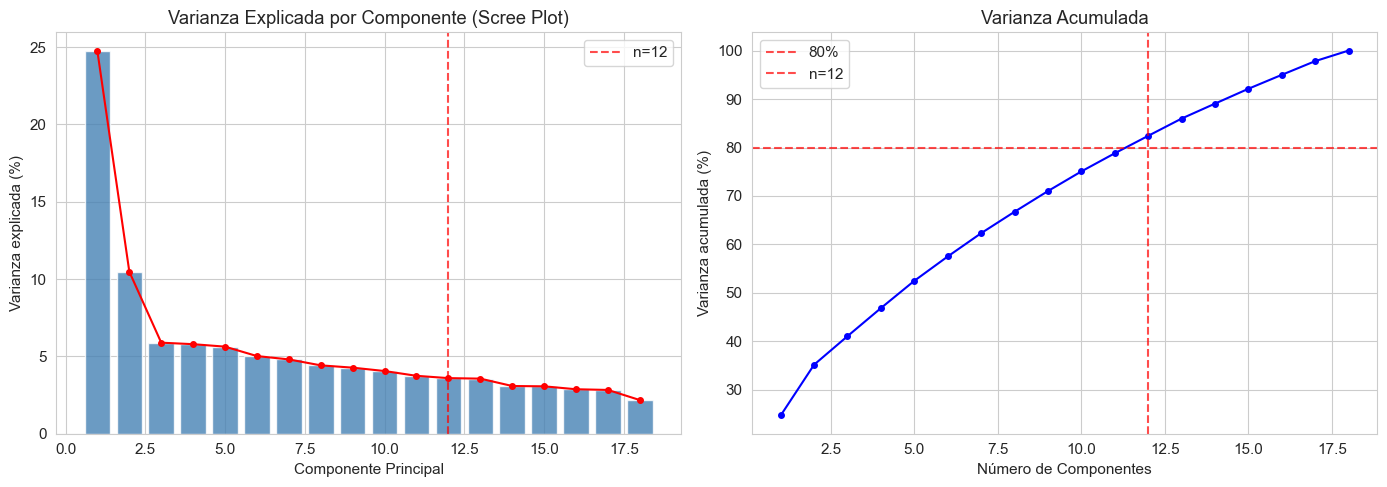

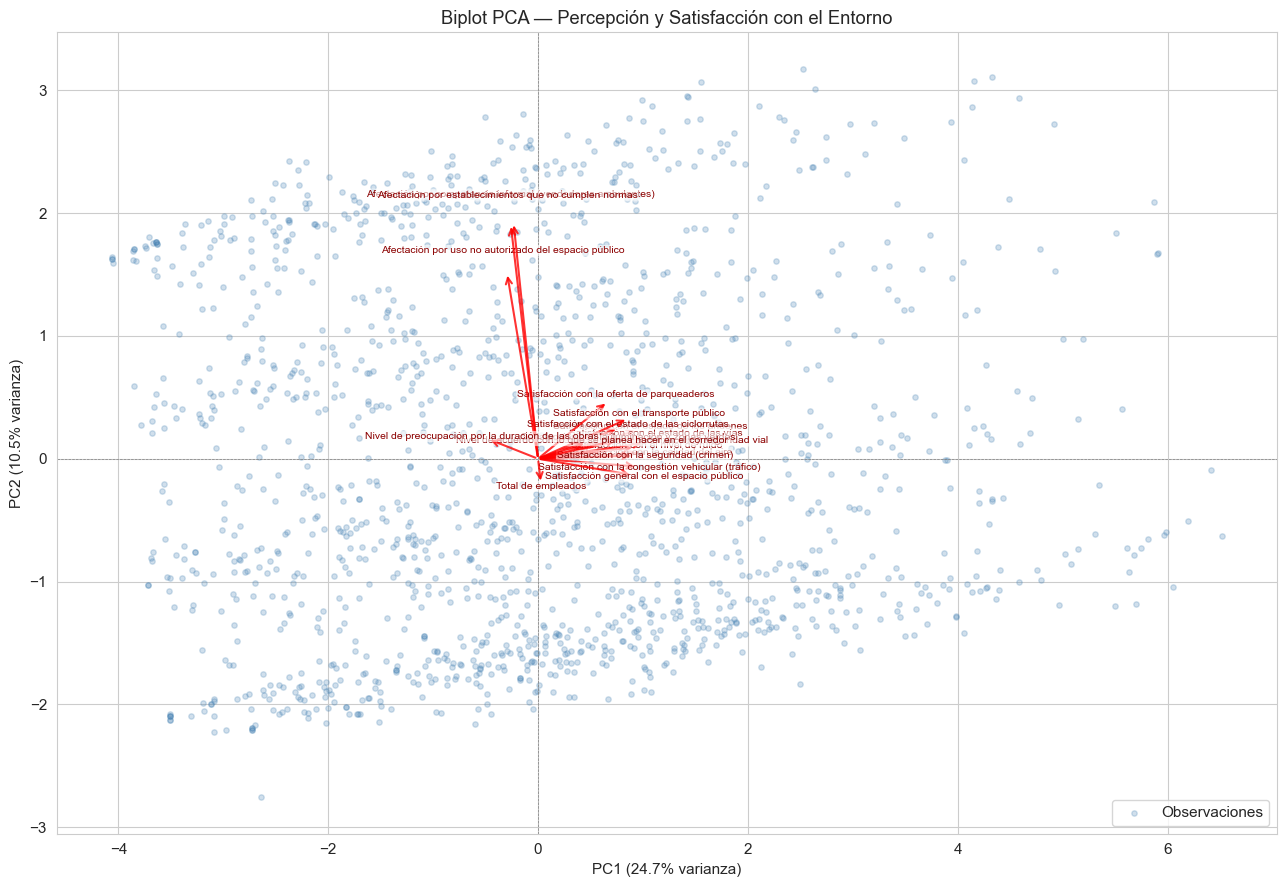


--- Cargas factoriales (loadings) ---
                                                               PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9   PC10   PC11   PC12
Satisfacción con la calidad del aire                         0.304  0.015 -0.192 -0.132 -0.274  0.080 -0.179  0.039 -0.123  0.088  0.095 -0.006
Satisfacción con el nivel de ruido                           0.288  0.029 -0.220  0.006 -0.158  0.287 -0.221 -0.196 -0.379 -0.021  0.189 -0.059
Satisfacción con el estado de los andenes                    0.297  0.073  0.139 -0.103  0.097 -0.038  0.485 -0.090 -0.114 -0.220  0.123  0.205
Satisfacción con el estado de las vías                       0.312  0.058  0.093 -0.107 -0.100 -0.192  0.333 -0.100 -0.026 -0.038 -0.053  0.143
Satisfacción con el estado de las ciclorrutas                0.239  0.078 -0.247  0.064  0.476  0.075  0.001  0.086  0.073  0.525 -0.144  0.503
Satisfacción con la señalización y seguridad vial            0.317  0.040 -0.060  0.016 -0.180 -0

In [11]:
# =============================================================================
# 6B. PCA — ESTIMACIÓN Y VISUALIZACIONES
# =============================================================================

nombres_cortos = [labels_pca[v] for v in vars_disponibles]

# --- Estandarizar ---
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(df_pca)

# --- PCA completo (para elegir número de componentes) ---
pca_full = PCA(random_state=42)
pca_full.fit(X_pca_scaled)

var_exp = pca_full.explained_variance_ratio_
var_cum = var_exp.cumsum()

# Número de componentes para ≥80% de varianza
n_comp = int((var_cum < 0.80).sum()) + 1
print(f"Componentes para ≥80% de varianza: {n_comp}")
print("\nVarianza explicada por componente:")
for i, (v, c) in enumerate(zip(var_exp, var_cum), 1):
    marker = ' ◄' if i == n_comp else ''
    print(f"  PC{i:>2}: {v*100:5.2f}%  (acumulada: {c*100:5.2f}%){marker}")

# --- Gráfico de varianza explicada ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', alpha=0.8)
ax1.plot(range(1, len(var_exp)+1), var_exp*100, 'ro-', markersize=4)
ax1.axvline(x=n_comp, color='red', linestyle='--', alpha=0.7, label=f'n={n_comp}')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_title('Varianza Explicada por Componente (Scree Plot)')
ax1.legend()

ax2.plot(range(1, len(var_cum)+1), var_cum*100, 'bo-', markersize=4)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80%')
ax2.axvline(x=n_comp, color='red', linestyle='--', alpha=0.7, label=f'n={n_comp}')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.set_title('Varianza Acumulada')
ax2.legend()

plt.tight_layout()
plt.savefig('fig_pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

# --- PCA final con n_comp componentes ---
pca = PCA(n_components=n_comp, random_state=42)
scores = pca.fit_transform(X_pca_scaled)
loadings = pca.components_.T  # shape: (n_vars, n_comp)

# --- Biplot PC1 vs PC2 ---
fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(scores[:, 0], scores[:, 1], alpha=0.25, s=15, color='steelblue', label='Observaciones')

scale = np.sqrt(len(df_pca)) * 0.08
for i, (lx, ly) in enumerate(loadings[:, :2]):
    ax.annotate('', xy=(lx*scale, ly*scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.8))
    ax.text(lx*scale*1.12, ly*scale*1.12, nombres_cortos[i],
            fontsize=7.5, color='darkred', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza)')
ax.set_title('Biplot PCA — Percepción y Satisfacción con el Entorno')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('fig_pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Tabla de cargas factoriales ---
loadings_df = pd.DataFrame(
    loadings,
    index=nombres_cortos,
    columns=[f'PC{i+1}' for i in range(n_comp)]
)
print("\n--- Cargas factoriales (loadings) ---")
print(loadings_df.round(3).to_string())

# 7. Modelo OLS

In [12]:
# =============================================================================
# 7A. OLS (LPM) CON ERRORES ROBUSTOS — Seguridad empeoró, sin dummies de tramo
# =============================================================================
# seguridad_empeoro = β₀ + β₁·fue_victima + β₂·obras_iniciadas
#                   + β₃·indice_satisfaccion + β₄·P43_1* (factores entorno)
#                   + β₅·tamano_empresa_* + β₆·sector_* + ε

y_ols  = df_encoded['seguridad_empeoro']
X_base = df_encoded.drop(columns=['seguridad_empeoro']).astype(int)

cols_tramo = [c for c in X_base.columns if c.startswith('tramo_')]
X_ols1 = X_base.drop(columns=cols_tramo).rename(columns=renombrar)
X_ols1_const = sm.add_constant(X_ols1)

ols1 = sm.OLS(y_ols, X_ols1_const).fit(cov_type='HC1')
print(ols1.summary())

# --- Tabla de coeficientes ordenada por p-valor ---
coef1 = pd.DataFrame({
    'Coeficiente': ols1.params,
    'Error std.':  ols1.bse,
    'IC 2.5%':     ols1.conf_int()[0],
    'IC 97.5%':    ols1.conf_int()[1],
    'p-valor':     ols1.pvalues,
}).drop(index='const').sort_values('p-valor')

print("\n--- Coeficientes ordenados por p-valor (referencia: Comercio | Micro) ---")
print(coef1.round(4).to_string())
print(f"\nR² = {ols1.rsquared:.4f} | R² ajustado = {ols1.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:      seguridad_empeoro   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     17.69
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           9.26e-65
Time:                        21:24:01   Log-Likelihood:                -1317.3
No. Observations:                2021   AIC:                             2683.
Df Residuals:                    1997   BIC:                             2817.
Df Model:                          23                                         
Covariance Type:                  HC1                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [13]:
# =============================================================================
# 7B. OLS (LPM) CON ERRORES ROBUSTOS — Seguridad empeoró, con dummies de tramo
# =============================================================================

X_ols2 = X_base.drop(columns=['obras_iniciadas']).rename(columns=renombrar)
X_ols2_const = sm.add_constant(X_ols2)

ols2 = sm.OLS(y_ols, X_ols2_const).fit(cov_type='HC1')
print(ols2.summary())

# --- Tabla de coeficientes ordenada por p-valor ---
coef2 = pd.DataFrame({
    'Coeficiente': ols2.params,
    'Error std.':  ols2.bse,
    'IC 2.5%':     ols2.conf_int()[0],
    'IC 97.5%':    ols2.conf_int()[1],
    'p-valor':     ols2.pvalues,
}).drop(index='const').sort_values('p-valor')

print("\n--- Coeficientes ordenados por p-valor (referencia: Comercio | Micro | Tramo 1) ---")
print(coef2.round(4).to_string())
print(f"\nR² = {ols2.rsquared:.4f} | R² ajustado = {ols2.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:      seguridad_empeoro   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     13.02
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           3.79e-74
Time:                        21:24:01   Log-Likelihood:                -1289.3
No. Observations:                2021   AIC:                             2661.
Df Residuals:                    1980   BIC:                             2891.
Df Model:                          40                                         
Covariance Type:                  HC1                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------